# Course lead scoring

In [113]:
import pandas as pd 
import numpy as np

In [114]:
df = pd.read_csv('Datasets/course_lead_scoring.csv')

In [115]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lead_source               1334 non-null   object 
 1   industry                  1328 non-null   object 
 2   number_of_courses_viewed  1462 non-null   int64  
 3   annual_income             1281 non-null   float64
 4   employment_status         1362 non-null   object 
 5   location                  1399 non-null   object 
 6   interaction_count         1462 non-null   int64  
 7   lead_score                1462 non-null   float64
 8   converted                 1462 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 102.9+ KB


In [116]:
df.isnull().sum()

lead_source                 128
industry                    134
number_of_courses_viewed      0
annual_income               181
employment_status           100
location                     63
interaction_count             0
lead_score                    0
converted                     0
dtype: int64

In [117]:
numerical = list(df.select_dtypes(include=['int64', 'float64']).columns)
categorical = list(df.select_dtypes(include=['object']).columns)

In [118]:
df[categorical] = df[categorical].fillna('NA')
df[numerical] = df[numerical].fillna(0)

In [119]:
df.industry.mode()

0    retail
Name: industry, dtype: object

# Correlation matrix of numerical variables

In [120]:
corr = df[numerical].corr()

In [121]:
corr

,number_of_courses_viewed,annual_income,interaction_count,lead_score,converted
number_of_courses_viewed,1.000000,0.009770,-0.023565,-0.004879,0.435914
annual_income,0.009770,1.000000,0.027036,0.015610,0.053131
interaction_count,-0.023565,0.027036,1.000000,0.009888,0.374573
lead_score,-0.004879,0.015610,0.009888,1.000000,0.193673
converted,0.435914,0.053131,0.374573,0.193673,1.000000


In [122]:
print(corr.loc['interaction_count', 'lead_score'])
print(corr.loc['number_of_courses_viewed', 'lead_score'])
print(corr.loc['number_of_courses_viewed', 'interaction_count'])
print(corr.loc['annual_income', 'interaction_count'])

0.009888182496913131
-0.004878998354681276
-0.023565222882888037
0.02703647240481443


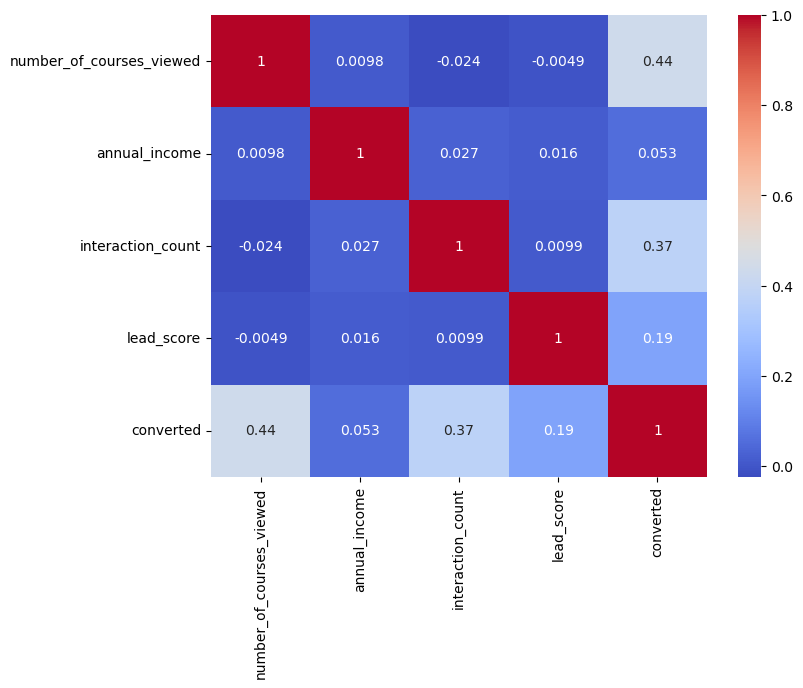

In [123]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

# Splitting the data

In [124]:
from sklearn.model_selection import train_test_split

In [125]:
y = df.converted.values

In [126]:
del df['converted']

In [127]:
df_full_train, df_test, y_full_train, y_test = train_test_split(
    df,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [128]:
df_train, df_val, y_train, y_val = train_test_split(
    df_full_train,
    y_full_train,
    test_size=0.25,
    random_state=42,
    stratify=y_full_train
)

In [129]:
print(np.mean(y_train))
print(np.mean(y_val))

0.6198630136986302
0.6177474402730375


# Mutual information

In [130]:
from sklearn.metrics import mutual_info_score

In [131]:
def mutual_info_churn_score(series):
    return mutual_info_score(series, y_train)

In [132]:
mi = df_train[categorical].apply(mutual_info_churn_score)
mi.sort_values(ascending=False)

lead_source          0.027719
employment_status    0.007696
industry             0.005959
location             0.001431
dtype: float64

In [133]:
round(mi, 2)

lead_source          0.03
industry             0.01
employment_status    0.01
location             0.00
dtype: float64

# One hot encoding

In [134]:
from sklearn.feature_extraction import DictVectorizer

In [135]:
train_dict = df_train.to_dict(orient='records')
val_dict = df_val.to_dict(orient='records')

In [136]:
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dict)
X_val = dv.transform(val_dict)

In [137]:
from sklearn.linear_model import LogisticRegression

In [138]:
model = LogisticRegression(
    solver='liblinear',
    C = 1.0,
    max_iter=1000,
    random_state=42
)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

In [139]:
y_pred = model.predict_proba(X_val)[:,1]

In [140]:
descision = (y_pred >= 0.5)

In [141]:
accuracy = (descision == y_val ).mean()
round(accuracy, 2)

np.float64(0.73)

In [142]:
original_accuracy = accuracy
original_accuracy

np.float64(0.7303754266211604)

In [143]:
print(df_train.columns.tolist())

['lead_source', 'industry', 'number_of_courses_viewed', 'annual_income', 'employment_status', 'location', 'interaction_count', 'lead_score']


# Feature elimination

In [145]:
features = df_train.columns
for feature in features:
    df_train_tmp = df_train.drop(columns=[feature])
    df_val_tmp = df_val.drop(columns=[feature])
    train_dict = df_train_tmp.to_dict(orient='records')
    val_dict = df_val_tmp.to_dict(orient='records')
    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(train_dict)
    X_val = dv.transform(val_dict)
    model = LogisticRegression(
        solver='liblinear',
        C=1.0,
        max_iter=1000,
        random_state=42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict_proba(X_val)[:,1]
    descision = y_pred >= 0.5
    accuracy = (descision == y_val).mean()
    difference = original_accuracy - accuracy
    print(feature, accuracy, difference)

lead_source 0.7372013651877133 -0.0068259385665528916
industry 0.7303754266211604 0.0
number_of_courses_viewed 0.621160409556314 0.10921501706484638
annual_income 0.863481228668942 -0.13310580204778155
employment_status 0.7337883959044369 -0.0034129692832765013
location 0.7303754266211604 0.0
interaction_count 0.6177474402730375 0.11262798634812288
lead_score 0.7303754266211604 0.0


In [146]:
C_values = [0.01, 0.1, 1, 10, 100]

for C in C_values:

    model = LogisticRegression(
        solver='liblinear',
        C=C,
        max_iter=1000,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict_proba(X_val)[:, 1]

    decision = y_pred >= 0.5

    accuracy = (decision == y_val).mean()

    print(f'C = {C}, accuracy = {round(accuracy, 3)}')

C = 0.01, accuracy = 0.73
C = 0.1, accuracy = 0.734
C = 1, accuracy = 0.73
C = 10, accuracy = 0.73
C = 100, accuracy = 0.73
